# Лабораторная работа 1. Перемножение матриц

**Цель работы:** реализовать умножение квадратных матриц на CPU и на GPU с использованием CUDA, проверить корректность результатов, измерить время выполнения и посчитать ускорение GPU относительно CPU.


In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from numba import njit

np.random.seed(42)
torch.manual_seed(42)

dtype = np.float32
sizes = [100, 500, 1000, 1500, 2000]

## Реализация на CPU

На CPU используется классический алгоритм умножения матриц с тремя вложенными циклами.

In [2]:
@njit
def matmul_cpu(A, B):
    n = A.shape[0]
    C = np.zeros((n, n), dtype=np.float32)

    for i in range(n):
        for j in range(n):
            s = 0.0
            for k in range(n):
                s += A[i, k] * B[k, j]
            C[i, j] = s

    return C

def benchmark_cpu(A, B):
    start = time.perf_counter()
    C = matmul_cpu(A, B)
    end = time.perf_counter()
    return end - start, C

## Реализация на GPU

В этой работе GPU-версия выполняется через **PyTorch** на устройстве  с `cuda`.

In [3]:
def benchmark_gpu(A, B):
    if not torch.cuda.is_available():
        return np.nan, None

    device = torch.device("cuda")

    A_t = torch.from_numpy(A).to(device)
    B_t = torch.from_numpy(B).to(device)

    torch.cuda.synchronize()
    start = time.perf_counter()
    C_t = torch.matmul(A_t, B_t)
    torch.cuda.synchronize()
    end = time.perf_counter()

    C = C_t.cpu().numpy()
    return end - start, C

## Прогрев

Перед основными измерениями выполняется небольшой прогрев CPU и GPU, чтобы убрать влияние первого запуска и компиляции.

In [4]:
A_test = np.random.rand(10, 10).astype(dtype)
B_test = np.random.rand(10, 10).astype(dtype)

matmul_cpu(A_test, B_test)

if torch.cuda.is_available():
    benchmark_gpu(A_test, B_test)

## Проведение эксперимента

Для каждого размера:
1. генерируются случайные матрицы `A` и `B`;
2. измеряется время умножения на CPU;
3. измеряется время умножения на GPU;
4. проверяется корректность результата;
5. вычисляется ускорение `CPU / GPU`.

In [5]:
results = []

for size in sizes:
    print(f"Матрицы {size}x{size}")

    A = np.random.rand(size, size).astype(dtype)
    B = np.random.rand(size, size).astype(dtype)

    cpu_time, C_cpu = benchmark_cpu(A, B)
    gpu_time, C_gpu = benchmark_gpu(A, B)

    if C_gpu is not None:
        correct = np.allclose(C_cpu, C_gpu, atol=1e-3)
        speedup = cpu_time / gpu_time if gpu_time > 0 else np.nan
    else:
        correct = None
        speedup = np.nan

    results.append({
        "Размер": size,
        "CPU, сек": cpu_time,
        "GPU, сек": gpu_time,
        "Ускорение": speedup,
        "Корректность": correct
    })

results_df = pd.DataFrame(results)
results_df["CPU, сек"] = results_df["CPU, сек"].round(6)
results_df["GPU, сек"] = results_df["GPU, сек"].round(6)
results_df["Ускорение"] = results_df["Ускорение"].round(2)

results_df

Матрицы 100x100
Матрицы 500x500
Матрицы 1000x1000
Матрицы 1500x1500
Матрицы 2000x2000


,Размер,"CPU, сек","GPU, сек",Ускорение,Корректность
0,100,0.000876,0.026244,0.03,True
1,500,0.057032,0.000782,72.94,True
2,1000,0.519009,0.000453,1145.23,True
3,1500,2.110887,0.000928,2275.31,True
4,2000,13.961655,0.159832,87.35,True


## Графики

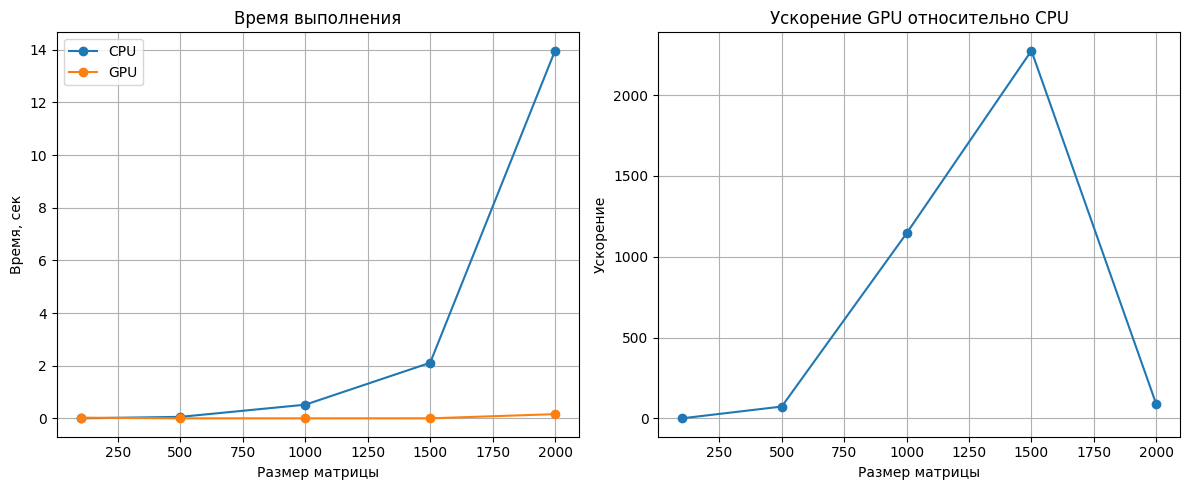

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(results_df["Размер"], results_df["CPU, сек"], marker="o", label="CPU")
plt.plot(results_df["Размер"], results_df["GPU, сек"], marker="o", label="GPU")
plt.xlabel("Размер матрицы")
plt.ylabel("Время, сек")
plt.title("Время выполнения")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(results_df["Размер"], results_df["Ускорение"], marker="o")
plt.xlabel("Размер матрицы")
plt.ylabel("Ускорение")
plt.title("Ускорение GPU относительно CPU")
plt.grid(True)

plt.tight_layout()
plt.show()

## Вывод

В ходе лабораторной работы были реализованы две версии умножения квадратных матриц:

1. Последовательная версия на CPU;
2. Версия на GPU с использованием CUDA через PyTorch.

Сравнение времени выполнения показало, что для маленькой матрицы 100×100 использование GPU оказалось невыгодным: CPU выполнил вычисления за 0.000876 с, а GPU — за 0.026244 с. Это связано с тем, что на малом объёме данных накладные расходы оказываются заметнее, чем выигрыш от параллельного выполнения.

Начиная с размера 500×500, GPU начинает значительно опережать CPU. В данном запуске ускорение составило:

1. 72.94 раза для 500×500;
2. 1145.23 раза для 1000×1000;
3. 2275.31 раза для 1500×1500.

Максимальное ускорение в проведённом эксперименте наблюдалось для матриц размера 1500×1500. Для размера 2000×2000 GPU также остался быстрее CPU (87.35 раза), однако по сравнению с предыдущей точкой ускорение заметно уменьшилось. В рамках данного запуска это может быть связано с ростом нагрузки на память и особенностями выполнения библиотечной GPU-операции на самом большом размере.

Таким образом, полученные графики показывают, что GPU особенно эффективно проявляет себя на средних и больших размерах матриц, тогда как для небольших матриц использование CPU может быть более выгодным. В целом цель работы достигнута: реализованы обе версии умножения матриц, проверена корректность, измерено время выполнения и рассчитано ускорение GPU относительно CPU.